In [ ]:
#importação de bibliotecas
import pandas as pd

In [ ]:
# planilha de clintes atendidos
df1 = pd.read_excel('dados.xlsx', sheet_name='Por Canal')

df1

,Estabelecimento,Data,Dia,Modo,Integração,Tabela Preço,N.Pessoas
0,JAPPA DA QUITANDA - ANÁLIA FRANCO,2025-08-01,Sexta,Salão,0,0,201
1,JAPPA DA QUITANDA - ANÁLIA FRANCO,2025-08-02,Sábado,Salão,0,0,266
2,JAPPA DA QUITANDA - ANÁLIA FRANCO,2025-08-03,Domingo,Salão,0,0,234
3,JAPPA DA QUITANDA - ANÁLIA FRANCO,2025-08-04,Segunda,Salão,0,0,231
4,JAPPA DA QUITANDA - ANÁLIA FRANCO,2025-08-05,Terça,Salão,0,0,213
...,...,...,...,...,...,...,...
163,JAPPA DA QUITANDA - BARRA SHOPPING,2025-09-23,Terça,Salão,0,1,210
164,JAPPA DA QUITANDA - BARRA SHOPPING,2025-09-24,Quarta,Salão,0,0,263
165,JAPPA DA QUITANDA - BARRA SHOPPING,2025-09-24,Quarta,Salão,0,1,255
166,JAPPA DA QUITANDA - BARRA SHOPPING,2025-09-25,Quinta,Salão,0,0,266


In [ ]:
df1.info()
df1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Estabelecimento  168 non-null    object
 1   Data             168 non-null    object
 2   Dia              168 non-null    object
 3   Modo             168 non-null    object
 4   Integração       168 non-null    int64 
 5   Tabela Preço     168 non-null    int64 
 6   N.Pessoas        168 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 9.3+ KB


In [ ]:
# planilha com quantidade de pedidos
df2 = pd.read_excel('dados.xlsx', sheet_name='Consumo de Produtos')

df2

,Estabelecimento,Cod.,Categoria,Descrição,Quant.,T. Categoria
0,JAPPA DA QUITANDA - ANÁLIA FRANCO,2000,RENTRADA,R SUNOMONO,0,RODIZIO
1,JAPPA DA QUITANDA - ANÁLIA FRANCO,2001,RENTRADA,R CAMARAO CATUPIRY,0,RODIZIO
2,JAPPA DA QUITANDA - ANÁLIA FRANCO,2002,RENTRADA,R CROQUETA SALMAO TERIYAKI,0,RODIZIO
3,JAPPA DA QUITANDA - ANÁLIA FRANCO,2003,R PRATOS QUENTES,R MIX DE COGUMELOS,0,RODIZIO
4,JAPPA DA QUITANDA - ANÁLIA FRANCO,2004,RENTRADA,R TEMPURA LEGUMES,0,RODIZIO
...,...,...,...,...,...,...
809,JAPPA DA QUITANDA - BARRA SHOPPING,3740,CERVEJA,DIAS DOS PAIS STELLA PURE GOLD,0,CERVEJAS
810,JAPPA DA QUITANDA - BARRA SHOPPING,3741,SOFT DRINKS,SPRITE,30,SOFT DRINKS
811,JAPPA DA QUITANDA - BARRA SHOPPING,3742,SOFT DRINKS,SPRITE ZERO,11,SOFT DRINKS
812,JAPPA DA QUITANDA - BARRA SHOPPING,3744,VINHO TINTO,ICHANKA MALBEC,0,VINHOS


In [11]:
df2.columns

Index(['Estabelecimento', 'Código', 'Categoria', 'Descrição', 'Quantidade',
       'Tipo Categoria'],
      dtype='object')

In [ ]:
# Renomando colunas específicas
df2 = df2.rename(
    columns={
        'Cod.' : 'Código',
        'Quant.' : 'Quantidade',
        'T. Categoria' : 'Tipo Categoria'
    }
)

In [12]:
df2.columns

Index(['Estabelecimento', 'Código', 'Categoria', 'Descrição', 'Quantidade',
       'Tipo Categoria'],
      dtype='object')

In [18]:
# Filtro por categorias específicas
df2 = df2[df2['Tipo Categoria'].isin(['DRINKS', 'SOFT DRINKS'])]
df2

,Estabelecimento,Código,Categoria,Descrição,Quantidade,Tipo Categoria
158,JAPPA DA QUITANDA - ANÁLIA FRANCO,3103,SOFT DRINKS,AGUA COM GAS,267,SOFT DRINKS
159,JAPPA DA QUITANDA - ANÁLIA FRANCO,3104,SOFT DRINKS,AGUA SEM GAS,318,SOFT DRINKS
160,JAPPA DA QUITANDA - ANÁLIA FRANCO,3105,SOFT DRINKS,COCA COLA,272,SOFT DRINKS
161,JAPPA DA QUITANDA - ANÁLIA FRANCO,3106,SOFT DRINKS,COCA COLA ZERO,281,SOFT DRINKS
162,JAPPA DA QUITANDA - ANÁLIA FRANCO,3107,SOFT DRINKS,GUARANA ANTARCTICA,257,SOFT DRINKS
...,...,...,...,...,...,...
802,JAPPA DA QUITANDA - BARRA SHOPPING,3667,SOFT DRINKS,MONSTER ENERGY,3,SOFT DRINKS
803,JAPPA DA QUITANDA - BARRA SHOPPING,3668,DRINKS AUTORAIS,DRINK MONSTER MANGO LOCO,10,DRINKS
807,JAPPA DA QUITANDA - BARRA SHOPPING,3704,SAKES,HAKUSHIKA JUNMAI CHOKARA 720ML,1,DRINKS
810,JAPPA DA QUITANDA - BARRA SHOPPING,3741,SOFT DRINKS,SPRITE,30,SOFT DRINKS


In [19]:
df1.columns

Index(['Estabelecimento', 'Data', 'Dia', 'Modo', 'Integração', 'Tabela Preço',
       'N.Pessoas'],
      dtype='object')

In [ ]:
# Calculo total de clientes por estabelecimento
n_pessoas = df1.groupby('Estabelecimento')['N.Pessoas'].sum()
n_pessoas

Estabelecimento
JAPPA DA QUITANDA - ANÁLIA FRANCO     13088
JAPPA DA QUITANDA - BARRA SHOPPING    26563
Name: N.Pessoas, dtype: int64

In [22]:
# Calculo total de produtos consumidos por categorias
qtd = df2.groupby(['Estabelecimento', 'Tipo Categoria'])['Quantidade'].sum() 
qtd

Estabelecimento                     Tipo Categoria
JAPPA DA QUITANDA - ANÁLIA FRANCO   DRINKS            13428
                                    SOFT DRINKS        9433
JAPPA DA QUITANDA - BARRA SHOPPING  DRINKS             1362
                                    SOFT DRINKS       28408
Name: Quantidade, dtype: int64

In [24]:
# Calculo de quantidade de pedidos por cliente
qtd_por_cliente = qtd / n_pessoas
qtd_por_cliente


Estabelecimento                     Tipo Categoria
JAPPA DA QUITANDA - ANÁLIA FRANCO   DRINKS            1.025978
                                    SOFT DRINKS       0.720737
JAPPA DA QUITANDA - BARRA SHOPPING  DRINKS            0.051274
                                    SOFT DRINKS       1.069458
dtype: float64

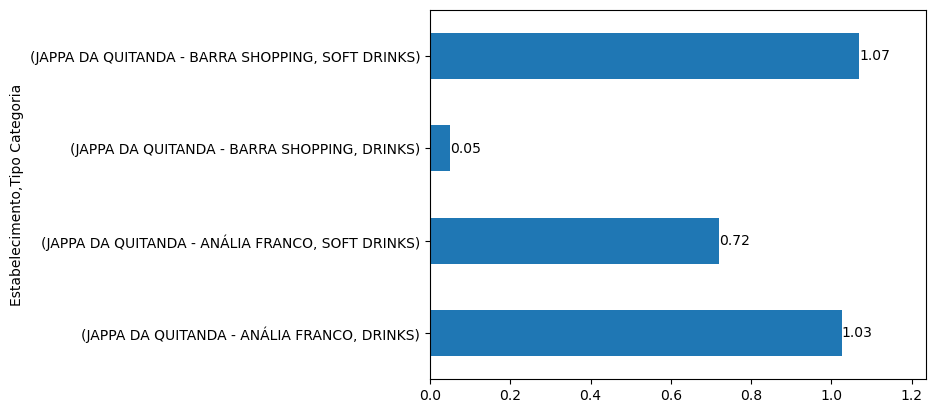

In [34]:
# Plotar gráfico para visaulização dos resultados
ax = qtd_por_cliente.plot.barh()
ax.bar_label(ax.containers[0], fmt='{:.2f}');
ax.set_xlim(0, ax.get_xlim()[1] * 1.1);


In [60]:
# 5 Produtos mais consumidos por categoria
top5_prods = df2.groupby(['Estabelecimento', 'Tipo Categoria', 'Descrição'])['Quantidade'].sum()
top5_prods  = top5_prods.sort_values(ascending=False)
top5_prods = top5_prods.groupby(['Estabelecimento', 'Tipo Categoria']).head(5)
top5_prods = top5_prods.sort_index()

top5_prods


Estabelecimento                     Tipo Categoria  Descrição                              
JAPPA DA QUITANDA - ANÁLIA FRANCO   DRINKS          CARAJILLO 43                                345
                                                    COSMOPOLITAN                                349
                                                    HAKUSHIKA HONJOSO SHU TRADICIONAL 720ML     350
                                                    JIM BEAM                                    346
                                                    MARGARITA                                   344
                                    SOFT DRINKS     CAFE DESCAFEINADO                           349
                                                    MATE DO CHEPH                               681
                                                    MATE MULE                                   333
                                                    SCHWEPPES CITRUS                            595
        

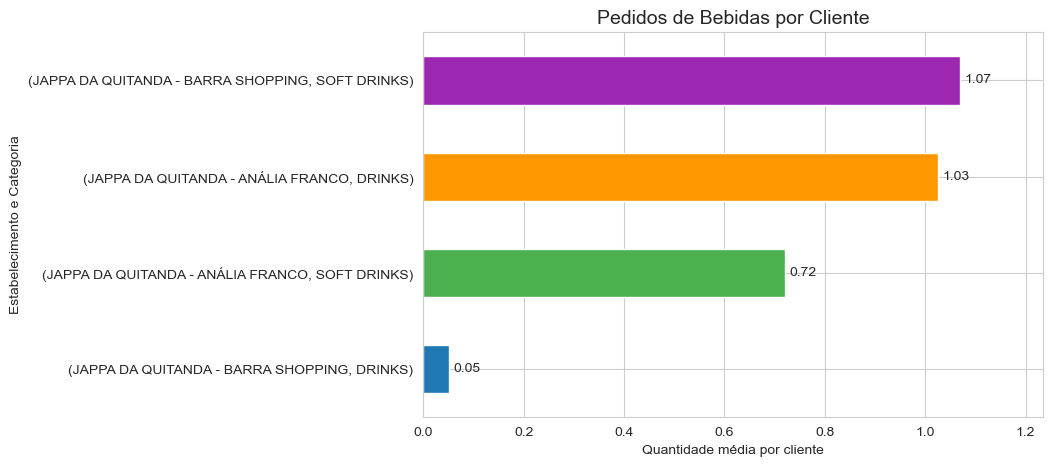

In [79]:
# Leve Melhoria do gráfico

# Importação e melhorias para gráficos
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.figure(figsize=(8,5))

# Ordenando clientes para melhor visualização
qtd_por_cliente = qtd_por_cliente.sort_values(ascending=True)

# Definindo cores específicas para cada barra
ax = qtd_por_cliente.plot.barh(
    color=["#1f77b4", "#4CAF50", "#FF9800", "#9C27B0"]
)

# Adicionando Titulo e legendas no gráfico
ax.set_title("Pedidos de Bebidas por Cliente", fontsize=14)
ax.set_xlabel('Quantidade média por cliente')
ax.set_ylabel('Estabelecimento e Categoria')
# Melhorando espaçamentos do gráfico
ax.bar_label(ax.containers[0], fmt='{:.2f}', padding=3)
ax.set_xlim(0, ax.get_xlim()[1] * 1.1)

plt.savefig("grafico_pedidos_por_cliente.png", dpi=300, bbox_inches="tight")

plt.show()

In [61]:
# Top 10 produtos mais consumidos
top10_prods = df2.groupby(['Estabelecimento', 'Tipo Categoria', 'Descrição'])['Quantidade'].sum()
top10_prods  = top10_prods.sort_values(ascending=False)
top10_prods = top10_prods.groupby(['Estabelecimento', 'Tipo Categoria']).head(10)
top10_prods = top10_prods.sort_index()

top10_prods

Estabelecimento                     Tipo Categoria  Descrição                              
JAPPA DA QUITANDA - ANÁLIA FRANCO   DRINKS          CARAJILLO 43                                345
                                                    COSMOPOLITAN                                349
                                                    GIN TONICA                                  337
                                                    HAKUSHIKA HONJOSO SHU TRADICIONAL 720ML     350
                                                    JIM BEAM                                    346
                                                    LICOR                                       344
                                                    MARGARITA                                   344
                                                    TROPICAL GIN                                340
                                                    VODKA SMIRNOFF                              344
        

In [ ]:
#transformando índices em colunas
top_prods_df = top10_prods.reset_index()


In [63]:
# Separando gráficos por categorias
drinks = top_prods_df[top_prods_df['Tipo Categoria']=='DRINKS']
soft_drinks = top_prods_df[top_prods_df['Tipo Categoria']=='SOFT DRINKS']

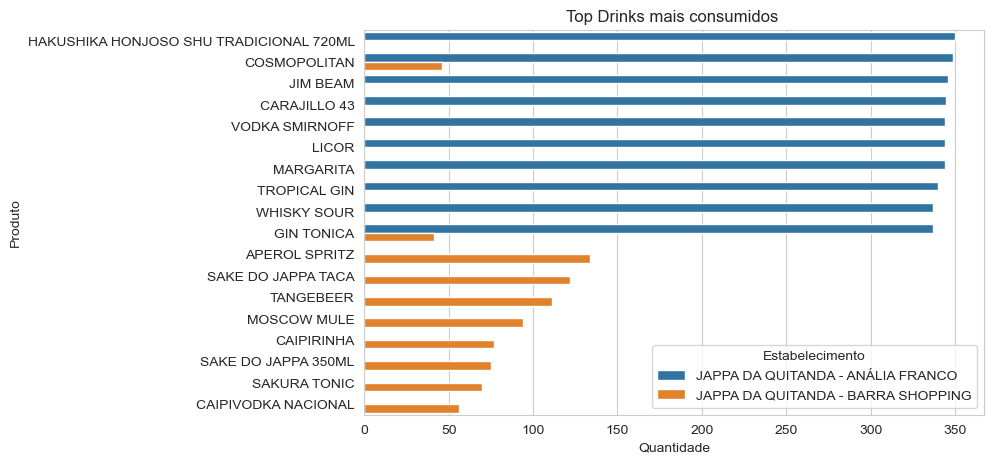

In [82]:
# Gráfico dos Drinks mais consumidos
sns.set_style('whitegrid')

plt.figure(figsize=(8,5))
drinks = drinks.sort_values("Quantidade", ascending=False)

sns.barplot(
    data=drinks,
    x='Quantidade',
    y='Descrição',
    hue="Estabelecimento"
)

plt.title("Top Drinks mais consumidos ")
plt.xlabel("Quantidade")
plt.ylabel("Produto")

plt.savefig("grafico_drinks.png", dpi=300, bbox_inches="tight")


plt.show()


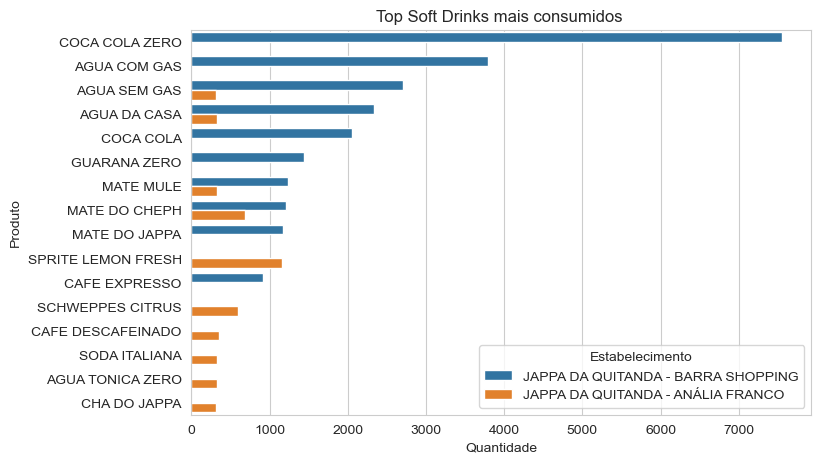

In [80]:
# Gráfico dos Soft Drinks mais consumidos
sns.set_style('whitegrid')

plt.figure(figsize=(8,5))
soft_drinks = soft_drinks.sort_values("Quantidade", ascending=False)

sns.barplot(
    data=soft_drinks,
    x='Quantidade',
    y='Descrição',
    hue="Estabelecimento"
)

plt.title("Top Soft Drinks mais consumidos ")
plt.xlabel("Quantidade")
plt.ylabel("Produto")

plt.savefig("grafico_soft_drinks.png", dpi=300, bbox_inches="tight")

plt.show()
